This programm performs the regionalisation of the calibration parameters and saves final maps.

In [3]:
# Python-Module für System- und Dateimanagement
import os  # Betriebssystem-Interaktionen
import sys  # Systembezogene Funktionen
from sys import platform  # Erkennen des Betriebssystems
import shutil  # Datei- und Verzeichnisoperationen
import glob  # Suchen von Dateien mit Muster
import stat  # Datei- und Verzeichnisrechte
import time  # Zeitmessung und -steuerung
import datetime  # Arbeiten mit Datum und Uhrzeit
import multiprocessing  # Parallele Verarbeitung
import subprocess  # Ausführen externer Prozesse
from subprocess import Popen, PIPE  # Alternative Möglichkeit für Subprozess-Kommunikation
import pickle  # Speichern und Laden von Python-Objekten (Serialisierung)
import ast  # Abstrakte Syntaxbäume (z. B. Umwandlung von Strings in Python-Objekte)
import configparser  # Einlesen und Schreiben von Konfigurationsdateien
from configparser import ConfigParser  # Alternative Schreibweise

# Numerische Berechnungen & Zufallszahlen
import array  # Arbeit mit Arrays
import random  # Zufallszahlengenerierung
import numpy as np  # Wissenschaftliches Rechnen mit Arrays
from collections import defaultdict, Counter

# Datenverarbeitung & Analyse 
import csv  # Lesen und Schreiben von CSV-Dateien
import xarray as xr  # Arbeiten mit multidimensionalen Arrays (z. B. für NetCDF-Daten)
import cftime  # Arbeiten mit Klimazeitdaten (z. B. NetCDF-Dateien)
import pandas as pd  # Datenanalyse und Tabellenverarbeitung

# Visualisierung
import matplotlib.pyplot as plt  # Erstellen von Diagrammen
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches  
from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib.cm as cm 

# Geografische Daten & Karten
import cartopy.crs as ccrs  # Koordinatenreferenzsysteme
import cartopy.feature as cfeature  # Geografische Features (z. B. Küstenlinien, Ländergrenzen)
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER  # Formatieren von Kartenrastern
import geopandas as gpd  # Verarbeiten von Geodaten, insbesondere Shapefiles
from shapely.geometry import Point  # Arbeiten mit geometrischen Objekten
# from osgeo import gdal  # Geodatenformate lesen/schreiben (z. B. Rasterdaten)

# Scipy
from scipy.spatial import cKDTree


# General settings

## Paths

In [2]:
root_path_STEP0 = '../Step0_preparationGRDCFiles'
root_path_BECK = '../Step0_preparationBECKparam/BECKparam_data/'
root_path_STEP2 = '../Step2_individualCalibrationFiles'

In [8]:
# Output paths for figures
output_path_graphs = 'Figures_Step3B_regionalisationFiles' + '/' + 'DATE' + date 
folder = output_path_graphs
os.makedirs(folder, exist_ok=True)

In [9]:
# Output path for upstream basins
OUTPUT_PATH_UPSTREAMBASIN = 'UpstreamBasin_PCSGrid'   + '/' + 'DATE' + date 
folder = OUTPUT_PATH_UPSTREAMBASIN 
os.makedirs(folder, exist_ok=True)

In [ ]:
# Output path for BestBasin nc-files
OUTPUT_PATH_BESTBASIN =  'RegCalibrBestBasin_PCSGrid'  + '/' + 'DATE' + date 
folder = OUTPUT_PATH_BESTBASIN
os.makedirs(folder, exist_ok=True)

In [ ]:
# Output paths for regional calibration parameter nc-files
OUTPUT_PATH_PCSGrid   = 'RegCalibrParam_PCSGrid'   + '/' + 'DATE' + date 
OUTPUT_PATH_CWatMGrid = 'RegCalibrParam_CWatMGrid' + '/' + 'DATE' + date
folder = OUTPUT_PATH_PCSGrid 
os.makedirs(folder, exist_ok=True)
folder = OUTPUT_PATH_CWatMGrid 
os.makedirs(folder, exist_ok=True)

In [3]:
# File with GRDC stations 
GRDCFilename = 'GRDC_40calibrationStations_FINAL'

In [4]:
# Date for output folder
date = '20260305'   

## Default values for calibration parameters

In [6]:
# Set default values for calibration parameters (taken from an original settings-files (Status: Jan 2024))
calibr_param_defaultValues = {
    'snowmeltcoef': 0.0027, 
    'crop_correct': 1.11,
    'soildepth_factor': 1.28, 
    'preferentialflowconstant': 4.5,
    'arnobeta_add':  0.39,      #  für CWatM:'arnobeta_add':  0.19, für C-CWatM: 'arnobeta_add':  0.39, 
    'alphadepl': 0.7,
    'factor_interflow': 2.8 ,
    'recessioncoeff_factor':  5.278, 
    'runoffconc_factor':  0.1,
    'manningsn':  1.86, 
    'normalstoragelimit': 0.44,
    'lakeafactor': 0.33,  
    'lakeevafactor': 1.52 }

## Names for OUTPUT calibration parameters files 

In [7]:
# Set variable namen für OUTPUT regional calibration parameters nc-files   
calibr_param_names = {
'snowmeltcoef'             :  'SnowMeltCoef' ,
'crop_correct'             :  'crop_correct' ,
'soildepth_factor'         :  'soildepth_factor' ,
'preferentialflowconstant' :  'preferentialFlowConstant' ,
'arnobeta_add'             :  'arnoBeta_add' ,
'alphadepl'                :  'alphaDepl',
'factor_interflow'         :  'factor_interflow' ,
'recessioncoeff_factor'    :  'recessionCoeff_factor' ,
'runoffconc_factor'        :  'runoffConc_factor' ,
'manningsn'                :  'manningsN' ,
'normalstoragelimit'       :  'normalStorageLimit' ,
'lakeafactor'              :  'lakeAFactor' ,
'lakeevafactor'            :  'lakeEvaFactor'  
}

# Basin data

In [12]:
# Read in GRDC-data-file (like in Step 3A)
xr_grdc = xr.open_dataset(root_path_STEP0 + '/GRDC_data/GRDC_calibrationStations/' + GRDCFilename + '_LatLonFit.nc')

# Hydrological basins from HydroBasins (like in Step 3A)
gdf_hybas = gpd.read_file(root_path_STEP0 + '/HydroBasins_data/hybas_eu_lev05_v1c.shp') 
xr_hybas = xr.open_dataset(root_path_STEP0 + '/HydroBasins_data/hybas_eu_lev05_v1c.nc')

# A netcdf-File with the same grid as the CWatM output grid is needed
xr_cwatm_grid = xr.open_dataset(root_path_STEP0 + '/CWatM_exampleGrid/discharge_daily.nc')

In [13]:
# Original choice of GRDC station IDs
list_of_station_IDs = xr_grdc['id'].values
print('Ursprüngliche Anzahl an IDs im GRDC-file: ' +  str(len(list_of_station_IDs)) + ' Stück')
print(list_of_station_IDs)

# Stations to be removed
###############     HAS TO BE COPIED FROM STEP 3A     #########################
list_of_removed_stations_IDs = np.array([ ])
###############     HAS TO BE COPIED FROM STEP 3A     #########################

# Final station choice
optimized_list_of_station_IDs = np.setdiff1d(list_of_station_IDs, list_of_removed_stations_IDs)
print(' ')
print('Final stations: ' + str(len(optimized_list_of_station_IDs)))
print(optimized_list_of_station_IDs) 

Ursprüngliche Anzahl an IDs im GRDC-file: 40 Stück
[6113050 6116200 6122260 6123400 6125100 6136145 6140400 6142150 6172050
 6212740 6226800 6227510 6232911 6233410 6233510 6243050 6335240 6337200
 6342501 6357500 6373304 6421100 6444600 6457870 6458450 6545050 6547110
 6574150 6606655 6646800 6729450 6730501 6731555 6742700 6744201 6781800
 6854250 6854700 6935051 6939050]
 
Übrige und finale (!) Anzahl an IDs für die Regionalisierung: 40 Stück
[6113050 6116200 6122260 6123400 6125100 6136145 6140400 6142150 6172050
 6212740 6226800 6227510 6232911 6233410 6233510 6243050 6335240 6337200
 6342501 6357500 6373304 6421100 6444600 6457870 6458450 6545050 6547110
 6574150 6606655 6646800 6729450 6730501 6731555 6742700 6744201 6781800
 6854250 6854700 6935051 6939050]


# --- Regionalisation ---

## 1. Input Physiographic and climatic parameteres
Data was prepared in Step0: preparaton of Beck parameters

In [4]:
# Loading mean annual maps of Physiographic and climatic parameteres
precip_map_originalGrip = xr.open_dataset( root_path_BECK + 'mean_annual_precipitation.nc' ) 
ai_map_originalGrip     = xr.open_dataset( root_path_BECK + 'mean_annual_ai.nc')
slope_map_originalGrip  = xr.open_dataset( root_path_BECK + 'topography_slope.nc' )

In [9]:
# Check format
def xr_LatLonShape(ds, filename):
    # Dimensionen
    print( filename, f'Dimensions:', ds.dims)           
    # Latitude und Longitude
    lat = ds['lat'].values
    lon = ds['lon'].values      
    print( filename, f'Longitudes:',  lon[:2], lon[-2:])
    print( filename, f'Latitudes:',   lat[:2], lat[-2:])
    # Gitterabstand berechnen
    dlat = abs(lat[1] - lat[0])
    dlon = abs(lon[1] - lon[0])
    print( filename, f'Grid spacing longitude: {dlon}°')
    print( filename, f'Grid spacing latitude: {dlat}°')
    print('---------------------------------')

# Datei-Format ausgeben lassen 
xr_LatLonShape(precip_map_originalGrip  , 'precip_map')
xr_LatLonShape(ai_map_originalGrip  , 'ai_map')
xr_LatLonShape(slope_map_originalGrip  , 'slope_map')

precip_map Dimensions: Frozen({'lon': 625, 'lat': 437})
precip_map Longitudes: [-10.62616933 -10.542836  ] [41.29049733 41.37383067]
precip_map Latitudes: [71.14285433 71.059521  ] [34.89285433 34.809521  ]
precip_map Grid spacing longitude: 0.08333333333333393°
precip_map Grid spacing latitude: 0.0833333333333286°
---------------------------------
ai_map Dimensions: Frozen({'lon': 625, 'lat': 437})
ai_map Longitudes: [-10.62616933 -10.542836  ] [41.29049733 41.37383067]
ai_map Latitudes: [71.14285433 71.059521  ] [34.89285433 34.809521  ]
ai_map Grid spacing longitude: 0.08333333333333393°
ai_map Grid spacing latitude: 0.0833333333333286°
---------------------------------
slope_map Dimensions: Frozen({'lon': 648, 'lat': 460})
slope_map Longitudes: [-11.625      -11.54166667] [42.20833333 42.29166667]
slope_map Latitudes: [72.125      72.04166667] [33.95833333 33.875     ]
slope_map Grid spacing longitude: 0.08333333333334281°
slope_map Grid spacing latitude: 0.0833333333333286°
------

In [10]:
# Keep data in correct format
precip_map        = precip_map_originalGrip                    
ai_map            = ai_map_originalGrip  

# Interpolate non-matching data
slope_map         = slope_map_originalGrip.interp(lat = ai_map.lat, lon = ai_map.lon, method = 'linear')

# Check format
xr_LatLonShape(slope_map , 'slope_map')

slope_map Dimensions: Frozen({'lat': 437, 'lon': 625})
slope_map Longitudes: [-10.62616933 -10.542836  ] [41.29049733 41.37383067]
slope_map Latitudes: [71.14285433 71.059521  ] [34.89285433 34.809521  ]
slope_map Grid spacing longitude: 0.08333333333333393°
slope_map Grid spacing latitude: 0.0833333333333286°
---------------------------------


## 2. Match each grid point to one HydroBasin Hybas-ID 

In [17]:
# Create GeoDataFrame
lon_values, lat_values = np.meshgrid(pet_map.lon.values, pet_map.lat.values)
points_df = pd.DataFrame({ 'lon': lon_values.ravel(), 'lat': lat_values.ravel()})
points_gdf = gpd.GeoDataFrame(points_df, geometry = gpd.points_from_xy(points_df.lon, points_df.lat), crs=gdf_hybas.crs)
# Match HYBAS_IDs
points_hybas = gpd.sjoin(points_gdf, gdf_hybas[['HYBAS_ID', 'geometry']], how='left', predicate='within')
# Back to raster
hybas_PCSgrid = points_hybas['HYBAS_ID'].values.reshape(len(pet_map.lat), len(pet_map.lon))
# Optional: set points without polygon to 0
hybas_PCSgrid = np.where(np.isnan(hybas_PCSgrid), 0, hybas_PCSgrid)

# convert numpy-array to xarray-DataArray
xr_hybas_PCSgrid_fast = xr.DataArray(hybas_PCSgrid, dims=['lat', 'lon'], coords={'lat': pet_map.lat, 'lon': pet_map.lon})
xr_hybas_PCSgrid_fast.name = 'sub_basin_mask'
xr_hybas_PCSgrid = xr_hybas_PCSgrid_fast

Anzahl der verschiedenen HybasIDs auf dem Kartenausschnitt der pet_map:  346


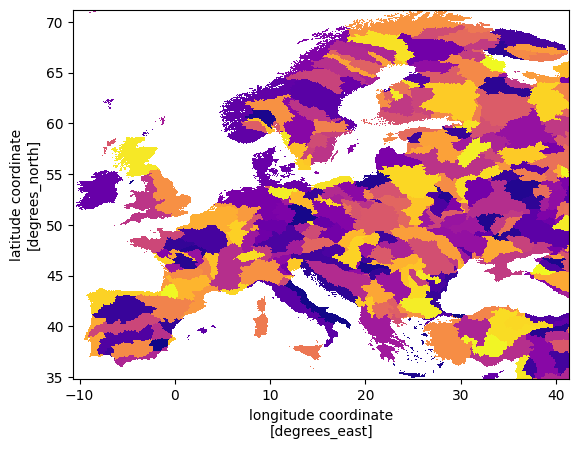

In [18]:
# Plot map with upstream basins

list_of_hybas_IDs_with0 = np.unique(xr_hybas_PCSgrid)
list_of_hybas_IDs = np.setdiff1d(list_of_hybas_IDs_with0, [0])
no_hybas_IDs = len(list_of_hybas_IDs) 

ids = np.setdiff1d(np.unique(xr_hybas_PCSgrid), [0])
vals = xr_hybas_PCSgrid.values
idx = np.zeros_like(vals, int)
for i, hid in enumerate(ids, 1):
    idx[vals == hid] = i
xr_idx = xr_hybas_PCSgrid.copy(data=idx)

rng = np.random.default_rng(42)
colors = plt.colormaps["plasma"].resampled(len(ids))(np.arange(len(ids)))[:, :3]
cmap = ListedColormap(np.vstack(([1,1,1], colors[rng.permutation(len(ids))])))

# Plot
xr_idx.plot(x='lon', y='lat', cmap=cmap, vmin=0, vmax=no_hybas_IDs , add_colorbar=False)
plt.savefig(output_path_graphs + '/' +  'figSTEP3B_Nr1_HybasBasins'  + '.jpg',  dpi=300, bbox_inches='tight')
plt.show()

## 3. Match each grid point to one GRDC-ID (based on C-CWatM upstream areas)

In [19]:
missing_optimized_list_of_station_IDs = []
basin_sizes = {}

# Size of UpstreamAreas 
for ID in optimized_list_of_station_IDs:
    try:
        # Load CWatM "cellArea_totalend.nc" from individual calibration
        upstream_area = xr.open_dataset(root_path_STEP2 + f'/outputFiles/{ID}/41_best/cellArea_totalend.nc')
        basin_sizes[ID] = (~np.isnan(upstream_area.cellArea_totalend)).sum().item()
    except Exception as e:
        basin_sizes[ID] = 0
        missing_optimized_list_of_station_IDs.append(ID)
        continue

if len(np.array(missing_optimized_list_of_station_IDs)) > 0: 
    print(f"WARNING: File 'cellArea_totalend.nc' was NOT found for the following station IDs:" , len(np.array(missing_optimized_list_of_station_IDs)), f" Stück")
    print(np.array(missing_optimized_list_of_station_IDs))

sorted_optimized_list_of_station_IDs = sorted(basin_sizes, key=basin_sizes.get)

ENTWARNUNG: File 'cellArea_totalend.nc' was found for all station IDs.


In [21]:
# Grid size of PhysioClimParameters 
x_size = len(ai_map.lon)
y_size = len(ai_map.lat)

cwatm_PCSgrid = np.zeros((y_size, x_size))

# convert to xarray-DataArray 
xr_cwatm_PCSgrid = xr.DataArray(cwatm_PCSgrid, dims=['lat', 'lon'], coords={'lat': pet_map.lat, 'lon': pet_map.lon})
xr_cwatm_PCSgrid_ID = xr.DataArray(cwatm_PCSgrid, dims=['lat', 'lon'], coords={'lat': pet_map.lat, 'lon': pet_map.lon})

# Fill aray with GRDC-IDs 
for ID in sorted_optimized_list_of_station_IDs:   
    try: 
        upstream_area = xr.open_dataset(root_path_STEP2 + '/outputFiles/' + str(ID) + '/41_best/' + 'cellArea_totalend.nc') 
    except Exception as e:
        continue

    upstream_area_PCSgrid = upstream_area.interp(lat = pet_map.lat, lon = pet_map.lon, method = 'nearest')

    xr_cwatm_PCSgrid_ID = xr.where(~np.isnan(upstream_area_PCSgrid.cellArea_totalend), ID, 0)

    mask = ~np.isnan(upstream_area_PCSgrid.cellArea_totalend)
    xr_cwatm_PCSgrid = xr.where(mask,  ID,  xr_cwatm_PCSgrid )    

# Save as netcdf file
xr_cwatm_PCSgrid.to_netcdf(OUTPUT_PATH_UPSTREAMBASIN + '/' +  'upstream_basin_map' + '_' + date + '.nc')

In [22]:
# Check basin overlap

GRDC_uniqvars_with0 = np.unique(xr_cwatm_PCSgrid.values)
GRDC_uniqvars = np.setdiff1d(GRDC_uniqvars_with0, [0])

GRDC_missing = np.setdiff1d(optimized_list_of_station_IDs, GRDC_uniqvars)

if len(GRDC_missing) > 0: 
    print(f"WARNING: The following GRDC-basins are contained within larger basins and are thus not in 'upstream_basin_map' any more.")
    print(GRDC_missing)

ENTWARNUNG: Alle GRDC IDs kommen noch in 'upstream_basin_map' vor. 


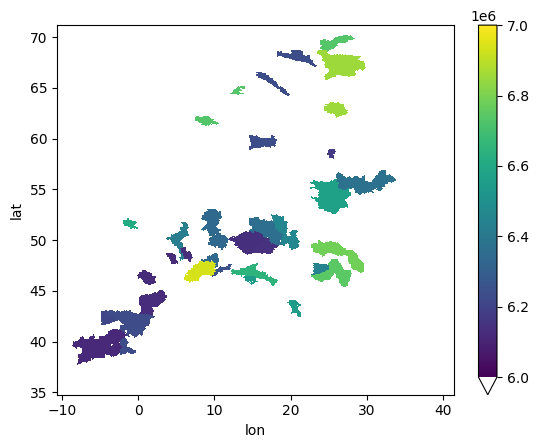

In [23]:
# Plot upstream basins
cmap = plt.colormaps["viridis"].copy()     
cmap.set_under("white")
xr_cwatm_PCSgrid.plot(x='lon', y='lat', vmin = 0.6*1e7, vmax= 0.7*1e7, cmap=cmap)
plt.savefig(output_path_graphs + '/' +  'figSTEP3B_Nr2_UpstreamAreas.jpg',  dpi=300, bbox_inches='tight')
plt.show()

## 4. Computation of Beck's Dissimilarity and selection of the 3 best basin for the grid cell 

In [28]:
# Read in GRDC-data-file
xr_grdc = xr.open_dataset(root_path_STEP0 + '/GRDC_data/GRDC_calibrationStations/' + GRDCFilename + '_LatLonFit.nc')
# Read in HybasBasin-data-file
xr_hybas = xr.open_dataset(root_path_STEP0 + '/HydroBasins_data/hybas_eu_lev05_v1c.nc')

# Read in UpstreamArea-data-file (created in 3.) 
xr_upstream = xr.open_dataset(OUTPUT_PATH_UPSTREAMBASIN + '/' + 'upstream_basin_map' + '_' + date + '.nc')

Berechnungsmethode 'priorMethod_BigBasins' ausgewählt'!


The dissimilarity S(i,j)  computed by Becks is composed by the value of the predictors on the i,j grid point, the value of the preductor on each regions and the Interquartile Range of theses predictors, thoses elements are computed below

In [29]:
# Merged array of PhyClimParameters + Upstream area (from C-CWatM) 
precip_upstream       = xr.merge([precip_map, xr_upstream])
ai_upstream           = xr.merge([ai_map, xr_upstream])
slope_upstream        = xr.merge([slope_map, xr_upstream])

# Merged array of PhyClimParameters + Hydro Basins 
precip_hybas          = xr.merge([precip_map, xr_hybas])
ai_hybas              = xr.merge([ai_map, xr_hybas])
slope_hybas           = xr.merge([slope_map, xr_hybas])

In [30]:
# calculate means
precip_upstream_region      = precip_upstream.groupby('__xarray_dataarray_variable__').mean(skipna=True)
ai_upstream_region          = ai_upstream.groupby('__xarray_dataarray_variable__').mean(skipna=True)
slope_upstream_region       = slope_upstream.groupby('__xarray_dataarray_variable__').mean(skipna=True)

precip_hybas_region      = precip_hybas.groupby('sub_basin_mask').mean(skipna=True)
ai_hybas_region          = ai_hybas.groupby('sub_basin_mask').mean(skipna=True)
slope_hybas_region       = slope_hybas.groupby('sub_basin_mask').mean(skipna=True)

In [31]:
# Calculate Inter-Quantile-Range v
IQR_precip      = precip_map.mean_annual_precipitation.quantile(0.75, dim=["lon", "lat"]) - precip_map.mean_annual_precipitation.quantile(0.25, dim=["lon", "lat"])
IQR_ai          = ai_map.mean_annual_ai.quantile(0.75, dim=["lon", "lat"]) - ai_map.mean_annual_ai.quantile(0.25, dim=["lon", "lat"])
IQR_slope       = slope_map.slope.quantile(0.75, dim=["lon", "lat"]) - slope_map.slope.quantile(0.25, dim=["lon", "lat"])
# Dictionary of IQR 
IQR = {}
IQR['precip'],  IQR['ai'], IQR['slope']  =  IQR_precip.values, IQR_ai.values, IQR_slope.values

### Averaging of PhyClimParameters 
Compare, within the hydrobins, the mean values of the PhyClim parameters with those of the CWatM upstream basins, and then downscale them to a point grid.  
Do not maintain a distinction between donor and acceptor basins, i.e., regionalize both the donor and the acceptor basins in the same way.

In [36]:
list_of_hybas_IDs_with0 = np.unique(xr_hybas_PCSgrid)
list_of_hybas_IDs = np.setdiff1d(list_of_hybas_IDs_with0, [0])

list_of_upstream_IDs_with0 = np.unique(xr_upstream['__xarray_dataarray_variable__'].values)
list_of_upstream_IDs = np.setdiff1d(list_of_upstream_IDs_with0, [0])

ENTWARNUNG: 'list_of_upstream_IDs' und 'optimized_list_of_station_IDs' sind identisch.


In [37]:
BECK_KEYS = ['precip', 'ai', 'slope']

hybas_best_basin_1  = {}
hybas_best_basin_2  = {}
hybas_best_basin_3  = {}

for hybas_ID in list_of_hybas_IDs :
    if hybas_ID != 0 :
        Z_hybas = {}      # PhyClimParameter for each hydrological basin 
        Zn = {}           # PhyClimParameter for each C-CWatM upstream catchment
        S_hybas = {}      # PhyClimParmeter-Similarity between hydrologischen basins und C-CWatM upstream catchments 

        # PhyClimParameters for Hybas basins 
        Z_hybas['precip']       = precip_hybas_region.mean_annual_precipitation.sel(sub_basin_mask=hybas_ID).values
        Z_hybas['ai']           = ai_hybas_region.mean_annual_ai.sel(sub_basin_mask=hybas_ID).values   
        Z_hybas['slope']        = slope_hybas_region.slope.sel(sub_basin_mask=hybas_ID).values
        
        # PhyClimParameter for C-CWatM upstream catchments 
        for ID in list_of_upstream_IDs:
            Zn['precip']       = precip_upstream_region.mean_annual_precipitation.sel(__xarray_dataarray_variable__=ID).values
            Zn['ai']           = ai_upstream_region.mean_annual_ai.sel(__xarray_dataarray_variable__=ID).values
            Zn['slope']        = slope_upstream_region.slope.sel(__xarray_dataarray_variable__=ID).values

            # PhyClimParameter similarity 
            Sijn = np.sum([np.linalg.norm(Z_hybas[key] - Zn[key])/IQR[key] for key in BECK_KEYS])
            S_hybas[ID]= Sijn

        # Find 3 best matches
        sorted_IDs = sorted(S_hybas, key=S_hybas.get)
        sorted_S_hybas = {ID : S_hybas[ID] for ID in sorted_IDs}
        hybas_best_basin_1 [str(hybas_ID)] = sorted_IDs [0]
        hybas_best_basin_2 [str(hybas_ID)] = sorted_IDs [1]
        hybas_best_basin_3 [str(hybas_ID)] = sorted_IDs [2]

In [38]:
# Grid size of PhysioClimParameters
y_size = len(ai_map.lat)   # 437 Latitude
x_size = len(ai_map.lon)   # 625 Longitude

best_basin_1  = np.zeros((y_size, x_size))
best_basin_2  = np.zeros((y_size, x_size))
best_basin_3  = np.zeros((y_size, x_size))

for i in range(0, y_size) :  # i = 0..436
    for j in range(0, x_size) :      # j = 0..624

        hybas_ID = xr_hybas_PCSgrid.isel(lat=i, lon=j).values
        if hybas_ID !=0 : 
            ID = xr_cwatm_PCSgrid.isel(lat=i, lon=j).values
        
            # Case A: `xr_cwatm_PCSgrid ≠ 0` (i.e., the point x, y can be assigned a GRDC ID).  
            # For a donor basin, the assigned ID for point x, y should be the most optimal matching one.
            if ID != 0 :       
                best_basin_1 [i,j]  = hybas_best_basin_1 [str(hybas_ID)] 
                best_basin_2 [i,j]  = hybas_best_basin_2 [str(hybas_ID)] 
                best_basin_3 [i,j]  = hybas_best_basin_3 [str(hybas_ID)]  
        
            # Case B: xr_cwatm_PCSgrid = 0 (i.e., no GRDC ID has yet been assigned to point x, y).
            # For an acceptor basin, insert the GRDC ID computed above for point x, y
            else:  
                best_basin_1 [i,j]  = hybas_best_basin_1 [str(hybas_ID)] 
                best_basin_2 [i,j]  = hybas_best_basin_2 [str(hybas_ID)] 
                best_basin_3 [i,j]  = hybas_best_basin_3 [str(hybas_ID)]  
                

Berechnung des 1., 2. und 3. besten Upstream Basins [nach Variante 2!] wurde für jedes x-y-Raster abgeschlossen.


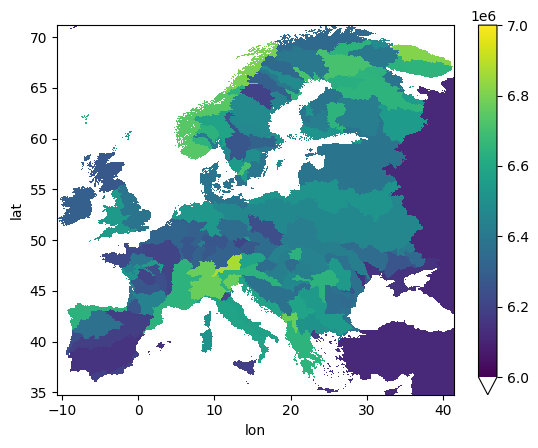

In [39]:
# convert to xarray DataFormat 
xr_best_basin_1 = xr.DataArray(best_basin_1, dims=[ 'lat', 'lon'], coords={'lon': pet_map.lon, 'lat': pet_map.lat})
xr_best_basin_2 = xr.DataArray(best_basin_2, dims=[ 'lat', 'lon'], coords={'lon': pet_map.lon, 'lat': pet_map.lat})
xr_best_basin_3 = xr.DataArray(best_basin_3, dims=[ 'lat', 'lon'], coords={'lon': pet_map.lon, 'lat': pet_map.lat})
xr_best_basin_1.name = 'xr_best_basin_1'
xr_best_basin_2.name = 'xr_best_basin_2'
xr_best_basin_3.name = 'xr_best_basin_3'

# Save as netcdf
xr_best_basin_1.to_netcdf(OUTPUT_PATH_BESTBASIN + '/' + '1st_BestUpstream_hybasAll' + '_' + date + '.nc')
xr_best_basin_2.to_netcdf(OUTPUT_PATH_BESTBASIN + '/' + '2nd_BestUpstream_hybasAll' + '_' + date + '.nc')
xr_best_basin_3.to_netcdf(OUTPUT_PATH_BESTBASIN + '/' + '3rd_BestUpstream_hybasAll' + '_'+  date + '.nc')

# Plotting
cmap = plt.colormaps["viridis"].copy()   
cmap.set_under("white")
# Plot
xr_basin_sum = 1/3* (xr_best_basin_1 + xr_best_basin_2 + xr_best_basin_3)
xr_basin_sum.plot(x='lon', y='lat', vmin = 0.6*1e7, vmax= 0.7*1e7, cmap=cmap)
plt.savefig(output_path_graphs + '/' +  'figSTEP3B_Nr3_RegCalibrBestBasin_regMethodHybasAll'  + '.jpg',  dpi=300, bbox_inches='tight')
plt.show()

## 5. Create the regionalised calibration parameters map 

In [42]:
# Read best basins created in step 4.
xr_best_basin_1 = xr.open_dataset(OUTPUT_PATH_BESTBASIN + '/' + '1st_BestUpstream_hybasAll' +  '_' + date + '.nc')
xr_best_basin_2 = xr.open_dataset(OUTPUT_PATH_BESTBASIN + '/' + '2nd_BestUpstream_hybasAll' +  '_' + date + '.nc')
xr_best_basin_3 = xr.open_dataset(OUTPUT_PATH_BESTBASIN + '/' + '3rd_BestUpstream_hybasAll' +  '_' + date + '.nc')

Berechnungsmethode 'regMethod_HybasAll' ausgewählt'!


#### Step 1: Read the best KGE values and the initial (START) KGE values for the different GRDC stations

In [43]:
# Save best KGE in dictionary
BEST_KGE = {}

for ID in optimized_list_of_station_IDs: 
    path_logFile = root_path_STEP2 + '/outputFiles/' + str(int(ID)) + '/runs_log.csv'
    if os.path.isfile(path_logFile):
        KGE_runs = pd.read_csv(path_logFile, sep=",", index_col=0, header=None)
        BEST_KGE [ID] = np.max(KGE_runs.values)
    else :
        BEST_KGE [ID] = np.nan 

print(f"GRDC station ID  : GRDC station's best KGE value")
for ID in optimized_list_of_station_IDs: 
    print(ID , '         :' ,  np.round(BEST_KGE [ID], 2))

GRDC station ID  : GRDC station's best KGE value
6113050          : 0.43
6116200          : 0.63
6122260          : 0.44
6123400          : 0.61
6125100          : 0.48
6136145          : 0.51
6140400          : 0.48
6142150          : 0.23
6172050          : 0.58
6212740          : 0.5
6226800          : 0.56
6227510          : -0.04
6232911          : 0.56
6233410          : 0.53
6233510          : 0.26
6243050          : 0.41
6335240          : 0.68
6337200          : 0.74
6342501          : 0.38
6357500          : 0.46
6373304          : 0.65
6421100          : 0.65
6444600          : 0.39
6457870          : 0.24
6458450          : 0.16
6545050          : 0.29
6547110          : 0.26
6574150          : 0.57
6606655          : 0.73
6646800          : 0.36
6729450          : 0.68
6730501          : 0.41
6731555          : 0.37
6742700          : 0.23
6744201          : 0.25
6781800          : 0.28
6854250          : 0.34
6854700          : 0.63
6935051          : 0.35
6939050        

In [44]:
# Save start KGE in dictionary
START_KGE = {}

for ID in optimized_list_of_station_IDs: 
    path_logFile = root_path_STEP2 + '/outputFiles/' + str(int(ID)) + '/runs_log.csv'
    if os.path.isfile(path_logFile):
        KGE_runs = pd.read_csv(path_logFile, sep=",", index_col=0, header=None)
        START_KGE [ID] = KGE_runs.values[0][0]
    else :
        START_KGE [ID] = np.nan 

print(f"GRDC station ID  : GRDC station's start KGE value")
for ID in optimized_list_of_station_IDs: 
    print(ID , '         :' ,  np.round(START_KGE [ID], 2))

GRDC station ID  : GRDC station's start KGE value
6113050          : 0.29
6116200          : 0.48
6122260          : 0.32
6123400          : 0.49
6125100          : 0.09
6136145          : 0.3
6140400          : 0.29
6142150          : 0.23
6172050          : 0.35
6212740          : -0.55
6226800          : -1.66
6227510          : -1.57
6232911          : 0.52
6233410          : 0.48
6233510          : 0.16
6243050          : 0.4
6335240          : 0.37
6337200          : 0.53
6342501          : 0.38
6357500          : 0.32
6373304          : 0.62
6421100          : 0.45
6444600          : 0.04
6457870          : 0.19
6458450          : 0.13
6545050          : 0.23
6547110          : 0.17
6574150          : 0.3
6606655          : 0.65
6646800          : 0.35
6729450          : 0.64
6730501          : 0.35
6731555          : 0.32
6742700          : 0.14
6744201          : 0.16
6781800          : -0.19
6854250          : -3.04
6854700          : 0.51
6935051          : 0.29
6939050     

In [45]:
# convert to xarray
no_of_station_IDs = len(optimized_list_of_station_IDs)
xr_BEST_KGE  = xr.DataArray(np.full(no_of_station_IDs, np.nan), dims='ID', coords={'ID': optimized_list_of_station_IDs}, name='BEST_KGE')

for ID in optimized_list_of_station_IDs:
    xr_BEST_KGE.loc[{'ID' : ID}] = BEST_KGE[ID]

### Step 2: Read best calibration parameters for GRDC stations

In [46]:
# Read keys
all_identified_keys = []
calibr_param_keys = []

ID = optimized_list_of_station_IDs [0]
path_iniFileBestKGE = root_path_STEP2 + '/outputFiles/' + str(ID) + '/41_best/settings_ccwatm_calibr_' + str(ID) + '-Run41_best.ini'
if os.path.isfile(path_iniFileBestKGE):
    config = configparser.ConfigParser()
    file = config.read(path_iniFileBestKGE)
    # Keys identifizieren
    for key in config['CALIBRATION']:
        all_identified_keys.append(key)
else: 
    print(f"File 'settings_ccwatm_calibr_{ID}-Run41_best.ini' does not exist.")

calibr_param_keys = all_identified_keys [3:]

Anzahl der finalen (!) calibration parameter:  7
['arnobeta_add', 'alphadepl', 'recessioncoeff_factor', 'manningsn', 'normalstoragelimit', 'lakeafactor', 'lakeevafactor']


In [47]:
# read values of calibration parameters
calibr_param_values = {}
for key in calibr_param_keys:
    calibr_param_values [key] = []

for ID in optimized_list_of_station_IDs: 
    path_iniFileBestKGE = root_path_STEP2 + '/outputFiles/' + str(ID) + '/41_best/settings_ccwatm_calibr_' + str(ID) + '-Run41_best.ini'
    if os.path.isfile(path_iniFileBestKGE):
        config = configparser.ConfigParser()
        file = config.read(path_iniFileBestKGE)
        # Values identifizieren
        for key in calibr_param_keys:
            calibr_param_values[key].append(float(config['CALIBRATION'][key]))
    else: 
        print(f"File 'settings_ccwatm_calibr_{ID}-Run41_best.ini' does not exist.")

In [48]:
# convert to xarray
XR_BestKGE_CalibrParam  = xr_BEST_KGE.to_dataset()

for key in calibr_param_keys:
    IDs = list(optimized_list_of_station_IDs)
    calibr_param_values_sorted = np.array([calibr_param_values[key][IDs.index(ID)] for ID in IDs])
    XR_BestKGE_CalibrParam [key] = xr.DataArray(calibr_param_values_sorted, dims='ID', coords={'ID': IDs})

print(XR_BestKGE_CalibrParam)

<xarray.Dataset>
Dimensions:                (ID: 40)
Coordinates:
  * ID                     (ID) int64 6113050 6116200 ... 6935051 6939050
Data variables:
    BEST_KGE               (ID) float64 0.4326 0.6315 0.4394 ... 0.3473 0.2716
    arnobeta_add           (ID) float64 0.1528 0.3379 0.08441 ... 0.4113 0.188
    alphadepl              (ID) float64 0.8406 0.6277 0.9537 ... 0.7459 0.6803
    recessioncoeff_factor  (ID) float64 5.321 5.04 4.136 ... 7.791 6.836 5.759
    manningsn              (ID) float64 0.2621 0.4179 7.067 ... 1.201 2.425
    normalstoragelimit     (ID) float64 0.8484 0.7386 0.5911 ... 0.4908 0.6129
    lakeafactor            (ID) float64 0.8629 0.7588 1.698 ... 0.3499 0.33
    lakeevafactor          (ID) float64 1.382 0.9693 1.036 ... 0.5199 0.594


### Step 3: Create the "Regionalized Calibration Parameter" maps 

In [50]:
# Grid size of PhysioClimParameters 
y_size = len(ai_map.lat)   # 437 Latitude
x_size = len(ai_map.lon)   # 625 Longitude

reg_calibr_param = {}

for key in calibr_param_keys: 
    data  = np.zeros((y_size, x_size))
    for i in range(0, y_size) :  # i = 0..436
        for j in range(0, x_size) :      # j = 0..624      
            # Find matching GRDC station
            best_basin_1 = xr_best_basin_1['xr_best_basin_1'].isel(lat=i, lon=j).values
            best_basin_2 = xr_best_basin_2['xr_best_basin_2'].isel(lat=i, lon=j).values
            best_basin_3 = xr_best_basin_3['xr_best_basin_3'].isel(lat=i, lon=j).values

            if best_basin_1 != 0 :
                data [i, j] = 1/3 * ( XR_BestKGE_CalibrParam [key].sel(ID = best_basin_1).values +
                                      XR_BestKGE_CalibrParam [key].sel(ID = best_basin_2).values + 
                                      XR_BestKGE_CalibrParam [key].sel(ID = best_basin_3).values )
            else: 
                data [i, j] = calibr_param_defaultValues [key]

    reg_calibr_param [key] =  data

In [51]:
# Save as netcdf files
xr_reg_calibr_param = {}

for key in calibr_param_keys:
    xr_reg_calibr_param [key] = xr.DataArray(reg_calibr_param[key], dims=[ 'lat', 'lon'], coords={'lon': pet_map.lon, 'lat': pet_map.lat}, name=key)
 
for key in calibr_param_keys:
    xr_reg_calibr_param [key].to_netcdf(OUTPUT_PATH_PCSGrid + '/' + 'PCSGrid' + '_' + calibr_param_names[key] + '.nc')

## 6. Adapt the regionalised calibration parameters map as a CWatM Input

In [52]:
xr_reg_calibr_param_CWatMGrid = {}

# Convert regional calibration parameter (Format: PCS grid) to regional calibration parameter (Format: CWatM grid)
for key in calibr_param_keys: 
    xr_reg_calibr_param_CWatMGrid [key] = xr_reg_calibr_param [key].interp(lat = xr_cwatm_grid.lat, lon = xr_cwatm_grid.lon, method = 'linear')

In [53]:
# Save as netcdf-files
for key in calibr_param_keys:
    xr_reg_calibr_param_CWatMGrid [key].to_netcdf(OUTPUT_PATH_CWatMGrid + '/' + calibr_param_names[key] + '.nc')